# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [7]:
# Import warnings

import warnings
warnings.filterwarnings("ignore")

In [8]:
# Import the libraries you will be using for analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

In [9]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 2.1.3
pandas version: 2.2.3
matplotlib version: 3.10.0
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [10]:
# Try loading one file

df = pd.read_parquet("2023-1.parquet")
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3041714 entries, 0 to 3066765
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            floa

In [5]:
df.shape

(3041714, 19)

In [17]:
df.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'airport_fee'],
      dtype='object')

In [18]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,1.0,N,161,141,2,9.3,1.00,0.5,0.00,0.0,1.0,14.30,2.5,0.00
1,2,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1.0,N,43,237,1,7.9,1.00,0.5,4.00,0.0,1.0,16.90,2.5,0.00
2,2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1.0,N,48,238,1,14.9,1.00,0.5,15.00,0.0,1.0,34.90,2.5,0.00
3,1,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1.0,N,138,7,1,12.1,7.25,0.5,0.00,0.0,1.0,20.85,0.0,1.25
4,2,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1.0,N,107,79,1,11.4,1.00,0.5,3.28,0.0,1.0,19.68,2.5,0.00


How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

In [11]:
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"])

In [12]:
df_sample = df.sample(frac=0.05, random_state=42)
df_sample.shape

(152086, 19)

In [13]:
df_sample.isnull().sum()

VendorID                    0
tpep_pickup_datetime        0
tpep_dropoff_datetime       0
passenger_count          3566
trip_distance               0
RatecodeID               3566
store_and_fwd_flag       3566
PULocationID                0
DOLocationID                0
payment_type                0
fare_amount                 0
extra                       0
mta_tax                     0
tip_amount                  0
tolls_amount                0
improvement_surcharge       0
total_amount                0
congestion_surcharge     3566
airport_fee              3566
dtype: int64

In [14]:
(df_sample.isnull().sum() / len(df_sample)) * 100

VendorID                 0.000000
tpep_pickup_datetime     0.000000
tpep_dropoff_datetime    0.000000
passenger_count          2.344726
trip_distance            0.000000
RatecodeID               2.344726
store_and_fwd_flag       2.344726
PULocationID             0.000000
DOLocationID             0.000000
payment_type             0.000000
fare_amount              0.000000
extra                    0.000000
mta_tax                  0.000000
tip_amount               0.000000
tolls_amount             0.000000
improvement_surcharge    0.000000
total_amount             0.000000
congestion_surcharge     2.344726
airport_fee              2.344726
dtype: float64

In [15]:
df_sample = df_sample.dropna()
df_sample.isnull().sum()

VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
congestion_surcharge     0
airport_fee              0
dtype: int64

In [16]:
(df_sample["trip_distance"] <= 0).sum()

np.int64(1767)

In [17]:
(df_sample["fare_amount"] <= 0).sum()

np.int64(56)

In [18]:
df_sample = df_sample[
    (df_sample["trip_distance"] > 0) &
    (df_sample["fare_amount"] > 0)
]

In [19]:
(df_sample["trip_distance"] <= 0).sum(), (df_sample["fare_amount"] <= 0).sum()

(np.int64(0), np.int64(0))

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [ ]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# Take a small percentage of entries from each hour of every date.
# Iterating through the monthly data:
#   read a month file -> day -> hour: append sampled data -> move to next hour -> move to next day after 24 hours -> move to next month file
# Create a single dataframe for the year combining all the monthly data

# Select the folder having data files
import os

# Select the folder having data files
os.chdir('/content/Assignments/EDA/data_NYC_Taxi/trip_records')

# Create a list of all the twelve files to read
file_list = os.listdir()

# initialise an empty dataframe
df = pd.DataFrame()


# iterate through the list of files and sample one by one:
for file_name in file_list:
    try:
        # file path for the current file
        file_path = os.path.join(os.getcwd(), file_name)

        # Reading the current file



        # We will store the sampled data for the current date in this df by appending the sampled data from each hour to this
        # After completing iteration through each date, we will append this data to the final dataframe.
        sampled_data = pd.DataFrame()

        # Loop through dates and then loop through every hour of each date

            # Iterate through each hour of the selected date

                # Sample 5% of the hourly data randomly

                # add data of this hour to the dataframe

        # Concatenate the sampled data of all the dates to a single dataframe
        df = # we initialised this empty DF earlier

    except Exception as e:
        print(f"Error reading file {file_name}: {e}")

After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [ ]:
# Store the df in csv/parquet
# df.to_parquet('')

## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [ ]:
# Load the new data file


In [20]:
# df.head()
df_sample.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
323412,1,2023-01-05 07:50:08,2023-01-05 08:02:04,2.0,1.90,1.0,N,239,236,1,13.5,2.5,0.5,2.50,0.0,1.0,20.00,2.5,0.0
1491266,2,2023-01-17 07:47:24,2023-01-17 08:00:50,5.0,1.86,1.0,N,239,162,1,14.2,0.0,0.5,3.64,0.0,1.0,21.84,2.5,0.0
2385670,2,2023-01-25 21:57:59,2023-01-25 22:00:33,1.0,0.50,1.0,N,162,170,1,5.1,1.0,0.5,2.02,0.0,1.0,12.12,2.5,0.0
766545,2,2023-01-09 19:36:54,2023-01-09 19:52:01,2.0,2.56,1.0,N,162,262,1,17.0,2.5,0.5,4.70,0.0,1.0,28.20,2.5,0.0
980153,1,2023-01-11 22:19:13,2023-01-11 22:32:37,1.0,2.80,1.0,N,164,231,1,14.9,3.5,0.5,3.98,0.0,1.0,23.88,2.5,0.0


In [21]:
# df.info()
df_sample.info()

<class 'pandas.core.frame.DataFrame'>
Index: 146726 entries, 323412 to 2043725
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               146726 non-null  int64         
 1   tpep_pickup_datetime   146726 non-null  datetime64[us]
 2   tpep_dropoff_datetime  146726 non-null  datetime64[us]
 3   passenger_count        146726 non-null  float64       
 4   trip_distance          146726 non-null  float64       
 5   RatecodeID             146726 non-null  float64       
 6   store_and_fwd_flag     146726 non-null  object        
 7   PULocationID           146726 non-null  int64         
 8   DOLocationID           146726 non-null  int64         
 9   payment_type           146726 non-null  int64         
 10  fare_amount            146726 non-null  float64       
 11  extra                  146726 non-null  float64       
 12  mta_tax                146726 non-null  flo

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [17]:
# Fix the index and drop any columns that are not needed

df_sample = df_sample.reset_index(drop=True)

In [18]:
df_sample = df_sample.drop(columns=["VendorID", "store_and_fwd_flag"])

In [19]:
df_sample.columns

Index(['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count',
       'trip_distance', 'RatecodeID', 'PULocationID', 'DOLocationID',
       'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount',
       'tolls_amount', 'improvement_surcharge', 'total_amount',
       'congestion_surcharge', 'airport_fee'],
      dtype='object')

**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [20]:
# Combine the two airport fee columns

df_sample["airport_fee"].value_counts(dropna=False)

airport_fee
0.00    133861
1.25     12865
Name: count, dtype: int64

**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [21]:
# check where values of fare amount are negative

df_sample[df_sample["fare_amount"] < 0]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee


Did you notice something different in the `RatecodeID` column for above records?

In [22]:
# Analyse RatecodeID for the negative fare amounts

df_sample.loc[df_sample["fare_amount"] < 0, "RatecodeID"].value_counts()

Series([], Name: count, dtype: int64)

In [23]:
# Find which columns have negative values

(df_sample.select_dtypes(include=["int64", "float64"]) < 0).sum()

passenger_count          0
trip_distance            0
RatecodeID               0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
congestion_surcharge     0
airport_fee              0
dtype: int64

In [24]:
# fix these negative values

numeric_cols = ["trip_distance", "fare_amount", "total_amount", "tip_amount", "tolls_amount"]

for col in numeric_cols:
    df_sample = df_sample[df_sample[col] >= 0]

### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column

In [23]:
# Find the proportion of missing values in each column

(df_sample.isnull().sum() / len(df_sample)) * 100

VendorID                 0.0
tpep_pickup_datetime     0.0
tpep_dropoff_datetime    0.0
passenger_count          0.0
trip_distance            0.0
RatecodeID               0.0
store_and_fwd_flag       0.0
PULocationID             0.0
DOLocationID             0.0
payment_type             0.0
fare_amount              0.0
extra                    0.0
mta_tax                  0.0
tip_amount               0.0
tolls_amount             0.0
improvement_surcharge    0.0
total_amount             0.0
congestion_surcharge     0.0
airport_fee              0.0
dtype: float64

**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [24]:
# Display the rows with null values
# Impute NaN values in 'passenger_count'
# df_sample[df_sample.isnull().any(axis=1)]

df_sample["passenger_count"] = df_sample["passenger_count"].fillna(
    df_sample["passenger_count"].median()
)

Did you find zeroes in passenger_count? Handle these.

**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [25]:
# Fix missing values in 'RatecodeID'
df_sample["RatecodeID"] = df_sample["RatecodeID"].fillna(
    df_sample["RatecodeID"].mode()[0]
)

**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [26]:
# handle null values in congestion_surcharge


df_sample["congestion_surcharge"] = df_sample["congestion_surcharge"].fillna(0)

Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [27]:
# Handle any remaining missing values

df_sample.isnull().sum()

VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
congestion_surcharge     0
airport_fee              0
dtype: int64

### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

In [28]:
# Describe the data and check if there are any potential outliers present
# Check for potential out of place values in various columns

df_sample.describe()

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
count,146726,146726,146726.000000,146726.000000,146726.000000,146726.000000,146726.000000,146726.000000,146726.000000,146726.000000,146726.000000,146726.000000,146726.000000,146726.000000,146726.000000,146726.000000,146726.000000
mean,2023-01-17 01:14:28.339933,2023-01-17 01:30:07.473045,1.363010,3.416774,1.439956,166.692215,164.280761,1.199671,18.493007,1.602726,0.497520,3.401421,0.531325,0.998732,27.308142,2.325440,0.109601
min,2022-12-31 14:39:43,2022-12-31 14:43:37,0.000000,0.010000,1.000000,1.000000,1.000000,1.000000,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000,1.010000,0.000000,0.000000
25%,2023-01-09 16:19:10.250000,2023-01-09 16:36:24.750000,1.000000,1.100000,1.000000,132.000000,113.000000,1.000000,8.600000,0.000000,0.500000,1.000000,0.000000,1.000000,15.480000,2.500000,0.000000
50%,2023-01-17 09:37:42,2023-01-17 09:55:40.500000,1.000000,1.800000,1.000000,162.000000,162.000000,1.000000,12.800000,1.000000,0.500000,2.800000,0.000000,1.000000,20.130000,2.500000,0.000000
75%,2023-01-24 17:16:06.750000,2023-01-24 17:33:43.500000,1.000000,3.350000,1.000000,234.000000,234.000000,1.000000,19.800000,2.500000,0.500000,4.200000,0.000000,1.000000,28.560000,2.500000,0.000000
max,2023-01-31 23:59:03,2023-02-01 13:23:48,6.000000,147.830000,99.000000,265.000000,265.000000,4.000000,656.800000,11.250000,0.800000,110.000000,42.000000,1.000000,667.100000,2.500000,1.250000
std,NaN,NaN,0.900949,4.451793,6.126991,63.979987,69.989084,0.450071,17.118240,1.785087,0.036092,3.771389,2.024919,0.029899,21.467002,0.637128,0.353538


In [28]:
df_sample[["trip_distance", "fare_amount", "total_amount", "passenger_count"]].describe(percentiles=[0.01, 0.99])

,trip_distance,fare_amount,total_amount,passenger_count
count,146726.000000,146726.000000,146726.000000,146726.000000
mean,3.416774,18.493007,27.308142,1.363010
std,4.451793,17.118240,21.467002,0.900949
min,0.010000,0.010000,1.010000,0.000000
1%,0.300000,4.400000,9.100000,0.000000
50%,1.800000,12.800000,20.130000,1.000000
99%,20.177500,70.200000,101.940000,5.000000
max,147.830000,656.800000,667.100000,6.000000


**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [32]:
# remove passenger_count > 6
df_sample = df_sample[df_sample["passenger_count"] <= 6]

In [33]:
df_sample = df_sample[~(
    (df_sample["trip_distance"] < 0.1) &
    (df_sample["fare_amount"] > 300)
)]

In [34]:
df_sample = df_sample[~(
    (df_sample["trip_distance"] == 0) &
    (df_sample["fare_amount"] == 0) &
    (df_sample["PULocationID"] != df_sample["DOLocationID"])
)]

In [35]:
df_sample = df_sample[df_sample["payment_type"] != 0]

In [36]:
# Continue with outlier handling

(df_sample.select_dtypes(include=["int64", "float64"]) < 0).sum()

passenger_count          0
trip_distance            0
RatecodeID               0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
congestion_surcharge     0
airport_fee              0
dtype: int64

In [ ]:
# Do any columns need standardising?

## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [37]:
df.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'airport_fee']

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`: Categorical
* `tpep_pickup_datetime`: datetime variable
* `tpep_dropoff_datetime`: DateTime
* `passenger_count`: Numerical
* `trip_distance`: Numerical
* `RatecodeID`: Categorical
* `PULocationID`: Categorical
* `DOLocationID`: Categorical
* `payment_type`: Categorical
* `pickup_hour`: Numerical 
* `trip_duration`: Numerical


The following monetary parameters belong in the same category, is it categorical or numerical?


* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

Numerical

##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

In [29]:
# Find and show the hourly trends in taxi pickups

df_sample["pickup_hour"] = df_sample["tpep_pickup_datetime"].dt.hour
df_sample["trip_duration"] = (
    df_sample["tpep_dropoff_datetime"] - df_sample["tpep_pickup_datetime"]
).dt.total_seconds() / 60

In [30]:
# Find and show the daily trends in taxi pickups (days of the week)

df_sample["pickup_day"] = df_sample["tpep_pickup_datetime"].dt.day_name()

In [31]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

daily_pickups = (
    df_sample["pickup_day"]
    .value_counts()
    .reindex(day_order)
)

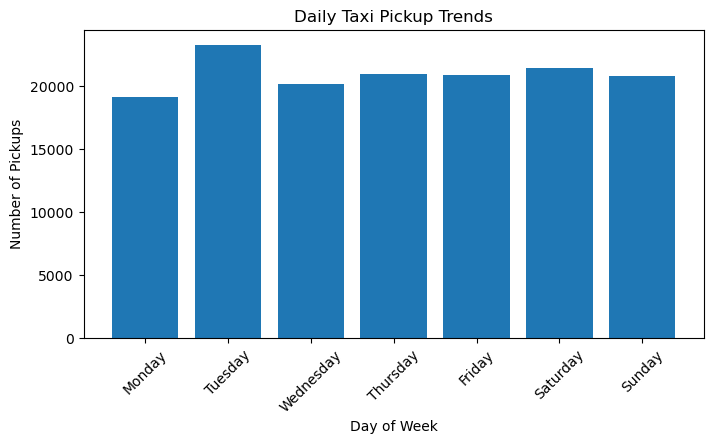

In [36]:
plt.figure(figsize=(8, 4))
plt.bar(daily_pickups.index, daily_pickups.values)
plt.xlabel("Day of Week")
plt.ylabel("Number of Pickups")
plt.title("Daily Taxi Pickup Trends")
plt.xticks(rotation=45)
plt.show()

In [35]:
plt.savefig("hourly_pickups.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [18]:
# Show the monthly trends in pickups

df_sample["pickup_month"] = df_sample["tpep_pickup_datetime"].dt.month

In [19]:
monthly_pickups = df_sample["pickup_month"].value_counts().sort_index()
monthly_pickups

pickup_month
1     148519
12         1
Name: count, dtype: int64

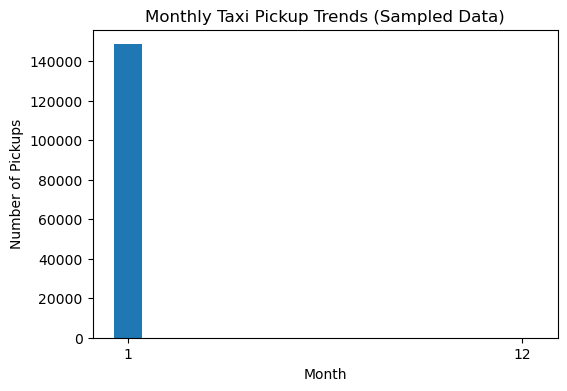

In [20]:
plt.figure(figsize=(6, 4))
plt.bar(monthly_pickups.index, monthly_pickups.values)
plt.xlabel("Month")
plt.ylabel("Number of Pickups")
plt.title("Monthly Taxi Pickup Trends (Sampled Data)")
plt.xticks(monthly_pickups.index)
plt.show()

##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [42]:
# Analyse the above parameters

(df_sample[["fare_amount", "tip_amount", "total_amount", "trip_distance"]] == 0).sum()

fare_amount          0
tip_amount       31781
total_amount         0
trip_distance        0
dtype: int64

In [23]:
(df_sample[["fare_amount", "tip_amount", "total_amount", "trip_distance"]] < 0).sum()

fare_amount       0
tip_amount        0
total_amount     10
trip_distance     0
dtype: int64

In [24]:
df_sample[["fare_amount", "tip_amount", "total_amount", "trip_distance"]].describe()

,fare_amount,tip_amount,total_amount,trip_distance
count,148520.000000,148520.000000,148520.000000,148520.000000
mean,18.613736,3.399157,27.410019,3.376829
std,17.473756,3.837773,21.780385,4.441666
min,0.000000,0.000000,-4.000000,0.000000
25%,8.600000,1.000000,15.450000,1.070000
50%,12.800000,2.740000,20.130000,1.790000
75%,20.000000,4.200000,28.560000,3.300000
max,656.800000,110.000000,667.100000,147.830000


Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [25]:
# Create a df with non zero entries for the selected parameters.

df_non_zero = df_sample[
    (df_sample["fare_amount"] > 0) &
    (df_sample["total_amount"] > 0)
]

In [26]:
(df_non_zero[["fare_amount", "total_amount"]] == 0).sum()

fare_amount     0
total_amount    0
dtype: int64

In [29]:
df_sample["pickup_month"] = df_sample["tpep_pickup_datetime"].dt.month

In [30]:
df_sample.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'airport_fee', 'pickup_hour',
       'trip_duration', 'pickup_day', 'pickup_month'],
      dtype='object')

**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

In [31]:
# Group data by month and analyse monthly revenue

monthly_revenue = (
    df_sample
    .groupby("pickup_month")["total_amount"]
    .sum()
    .sort_index()
)

monthly_revenue

pickup_month
1     4070923.12
12         12.96
Name: total_amount, dtype: float64

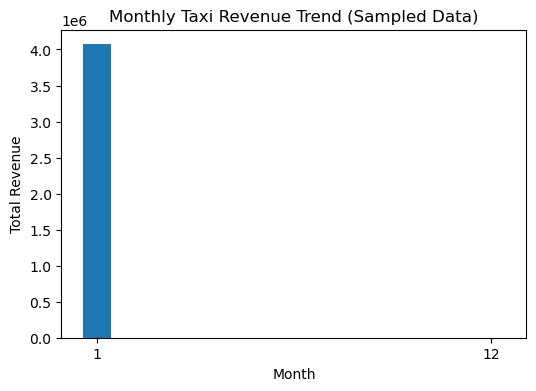

In [32]:
plt.figure(figsize=(6, 4))
plt.bar(monthly_revenue.index, monthly_revenue.values)
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.title("Monthly Taxi Revenue Trend (Sampled Data)")
plt.xticks(monthly_revenue.index)
plt.show()

**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

In [33]:
# Calculate proportion of each quarter

df_sample["pickup_quarter"] = df_sample["tpep_pickup_datetime"].dt.to_period("Q").astype(str)

In [34]:
quarterly_revenue = (
    df_sample
    .groupby("pickup_quarter")["total_amount"]
    .sum()
)
quarterly_revenue

pickup_quarter
2022Q4         12.96
2023Q1    4070923.12
Name: total_amount, dtype: float64

In [35]:
quarterly_proportion = quarterly_revenue / quarterly_revenue.sum()
quarterly_proportion

pickup_quarter
2022Q4    0.000003
2023Q1    0.999997
Name: total_amount, dtype: float64

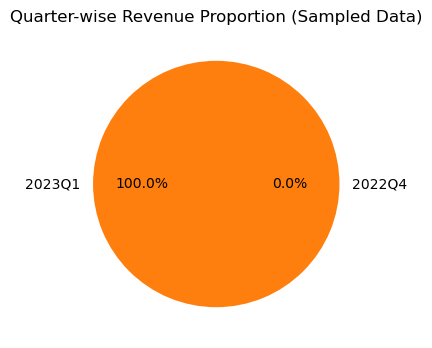

In [36]:
plt.figure(figsize=(6, 4))
plt.pie(
    quarterly_proportion.values,
    labels=quarterly_proportion.index,
    autopct="%1.1f%%"
)
plt.title("Quarter-wise Revenue Proportion (Sampled Data)")
plt.show()

**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

In [37]:
# Show how trip fare is affected by distance

df_distance_fare = df_sample[df_sample["trip_distance"] > 0]

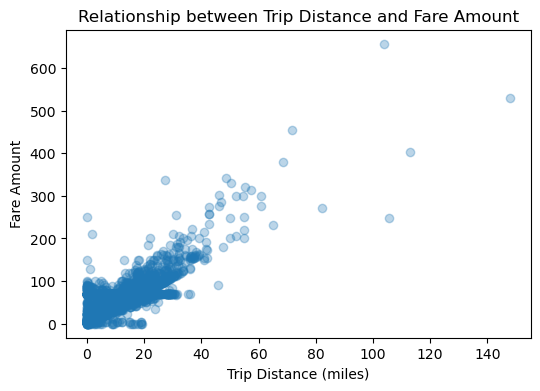

In [38]:
plt.figure(figsize=(6, 4))
plt.scatter(
    df_distance_fare["trip_distance"],
    df_distance_fare["fare_amount"],
    alpha=0.3
)
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Fare Amount")
plt.title("Relationship between Trip Distance and Fare Amount")
plt.show()

In [39]:
correlation = df_distance_fare["trip_distance"].corr(
    df_distance_fare["fare_amount"]
)
correlation

np.float64(0.9584174896587356)

**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

In [40]:
# Show relationship between fare and trip duration

df_fare_duration = df_sample[df_sample["trip_duration"] > 0]

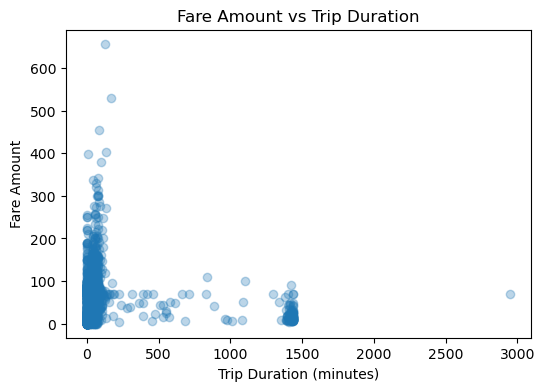

In [41]:
plt.figure(figsize=(6, 4))
plt.scatter(
    df_fare_duration["trip_duration"],
    df_fare_duration["fare_amount"],
    alpha=0.3
)
plt.xlabel("Trip Duration (minutes)")
plt.ylabel("Fare Amount")
plt.title("Fare Amount vs Trip Duration")
plt.show()

In [42]:
df_fare_duration["trip_duration"].corr(
    df_fare_duration["fare_amount"]
)

np.float64(0.22446764306444777)

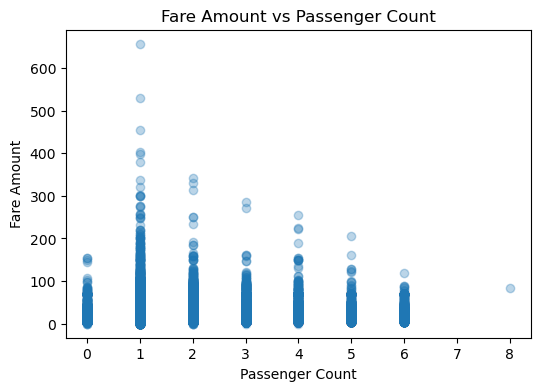

In [43]:
# Show relationship between fare and number of passengers

plt.figure(figsize=(6, 4))
plt.scatter(
    df_sample["passenger_count"],
    df_sample["fare_amount"],
    alpha=0.3
)
plt.xlabel("Passenger Count")
plt.ylabel("Fare Amount")
plt.title("Fare Amount vs Passenger Count")
plt.show()

In [44]:
df_sample["fare_amount"].corr(df_sample["passenger_count"])

np.float64(0.02917892749879907)

In [45]:
# Show relationship between tip and trip distance

df_tip_distance = df_sample[df_sample["trip_distance"] > 0]

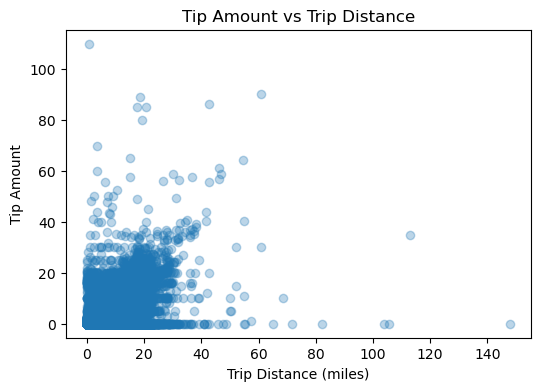

In [46]:
plt.figure(figsize=(6, 4))
plt.scatter(
    df_tip_distance["trip_distance"],
    df_tip_distance["tip_amount"],
    alpha=0.3
)
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Tip Amount")
plt.title("Tip Amount vs Trip Distance")
plt.show()

In [47]:
df_tip_distance["trip_distance"].corr(
    df_tip_distance["tip_amount"]
)

np.float64(0.6025515589834479)

**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

In [39]:
# Analyse the distribution of different payment types (payment_type).
payment_counts = df_sample["payment_type"].value_counts().sort_index()
payment_counts

payment_type
1    119703
2     25612
3       548
4       863
Name: count, dtype: int64

In [40]:
payment_labels = {
    1: "Credit Card",
    2: "Cash",
    3: "No Charge",
    4: "Dispute"
}

payment_counts.index = payment_counts.index.map(payment_labels)
payment_counts

payment_type
Credit Card    119703
Cash            25612
No Charge         548
Dispute           863
Name: count, dtype: int64

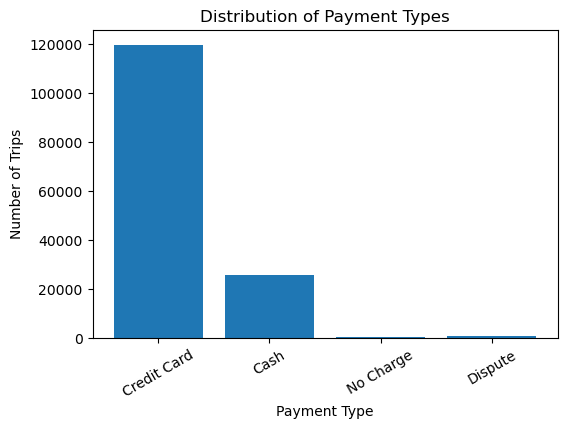

In [41]:
plt.figure(figsize=(6, 4))
plt.bar(payment_counts.index, payment_counts.values)
plt.xlabel("Payment Type")
plt.ylabel("Number of Trips")
plt.title("Distribution of Payment Types")
plt.xticks(rotation=30)
plt.show()


- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [ ]:
# !pip install geopandas

**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [43]:
# import geopandas as gpd

taxi_zones = gpd.read_file("taxi_zones.shp")
# Read the shapefile using geopandas
# zones = # read the .shp file using gpd
taxi_zones.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB
None


<Axes: >

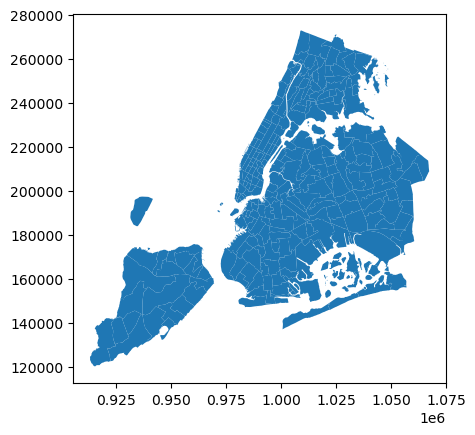

In [44]:
print(taxi_zones.info())
taxi_zones.plot()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [ ]:
# Merge zones and trip records using locationID and PULocationID



**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [45]:
# Group data by location and calculate the number of trips

df_zone_pickup = df_sample.merge(
    taxi_zones[["LocationID", "zone", "borough", "geometry"]],
    left_on="PULocationID",
    right_on="LocationID",
    how="left"
)

In [46]:
df_zone_pickup.head()

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,...,total_amount,congestion_surcharge,airport_fee,pickup_hour,trip_duration,pickup_day,LocationID,zone,borough,geometry
0,2023-01-05 07:50:08,2023-01-05 08:02:04,2.0,1.90,1.0,239,236,1,13.5,2.5,...,20.00,2.5,0.0,7,11.933333,Thursday,239.0,Upper West Side South,Manhattan,"POLYGON ((991168.979 226252.992, 991955.565 22..."
1,2023-01-17 07:47:24,2023-01-17 08:00:50,5.0,1.86,1.0,239,162,1,14.2,0.0,...,21.84,2.5,0.0,7,13.433333,Tuesday,239.0,Upper West Side South,Manhattan,"POLYGON ((991168.979 226252.992, 991955.565 22..."
2,2023-01-25 21:57:59,2023-01-25 22:00:33,1.0,0.50,1.0,162,170,1,5.1,1.0,...,12.12,2.5,0.0,21,2.566667,Wednesday,162.0,Midtown East,Manhattan,"POLYGON ((992224.354 214415.293, 992096.999 21..."
3,2023-01-09 19:36:54,2023-01-09 19:52:01,2.0,2.56,1.0,162,262,1,17.0,2.5,...,28.20,2.5,0.0,19,15.116667,Monday,162.0,Midtown East,Manhattan,"POLYGON ((992224.354 214415.293, 992096.999 21..."
4,2023-01-11 22:19:13,2023-01-11 22:32:37,1.0,2.80,1.0,164,231,1,14.9,3.5,...,23.88,2.5,0.0,22,13.400000,Wednesday,164.0,Midtown South,Manhattan,"POLYGON ((988787.425 210315.593, 988662.868 21..."


In [47]:
df_zone_pickup[["PULocationID", "zone", "borough"]].head()

,PULocationID,zone,borough
0,239,Upper West Side South,Manhattan
1,239,Upper West Side South,Manhattan
2,162,Midtown East,Manhattan
3,162,Midtown East,Manhattan
4,164,Midtown South,Manhattan


**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [48]:
# Merge trip counts back to the zones GeoDataFrame


pickup_counts = (
    df_sample["PULocationID"]
    .value_counts()
    .reset_index()
)

pickup_counts.columns = ["LocationID", "trip_count"]
pickup_counts.head()

,LocationID,trip_count
0,132,7764
1,237,7271
2,236,6669
3,161,6585
4,162,5216


In [49]:
zones_with_counts = taxi_zones.merge(
    pickup_counts,
    on="LocationID",
    how="left"
)

In [50]:
zones_with_counts["trip_count"] = zones_with_counts["trip_count"].fillna(0)

In [51]:
zones_with_counts[["LocationID", "zone", "borough", "trip_count"]].head()

,LocationID,zone,borough,trip_count
0,1,Newark Airport,EWR,3.0
1,2,Jamaica Bay,Queens,0.0
2,3,Allerton/Pelham Gardens,Bronx,2.0
3,4,Alphabet City,Manhattan,177.0
4,5,Arden Heights,Staten Island,0.0


The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

<Axes: >

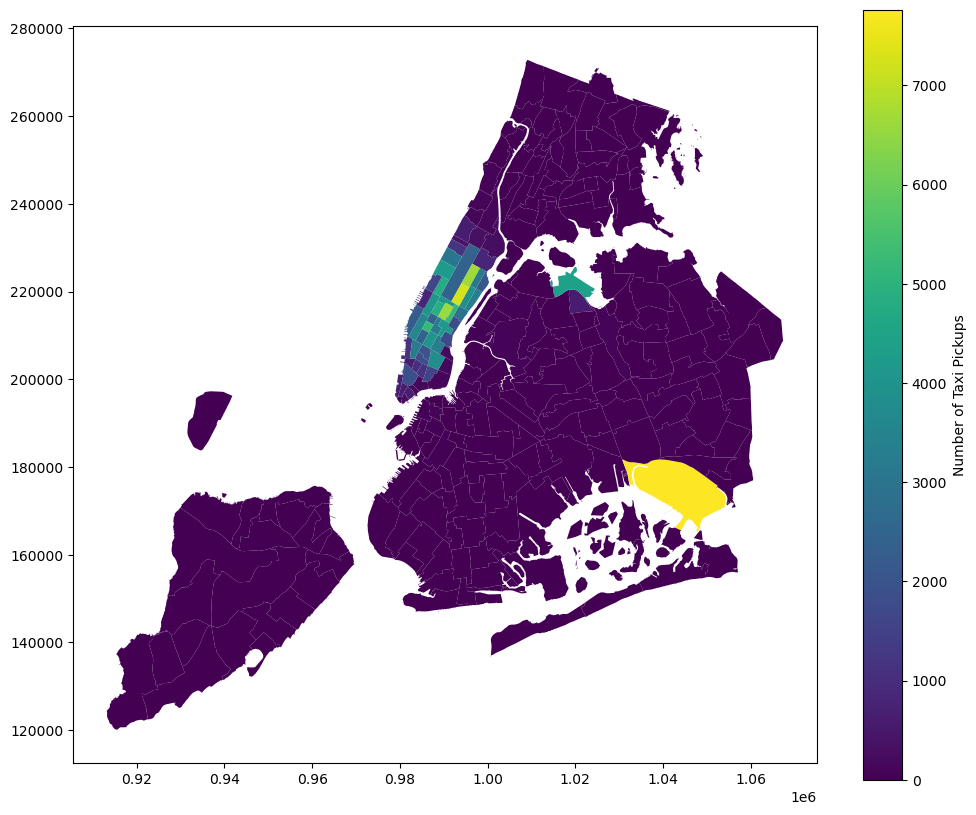

In [52]:
# Define figure and axis
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Plot the map and display it

zones_with_counts.plot(
    column="trip_count",
    ax=ax,
    legend=True,
    legend_kwds={
        "label": "Number of Taxi Pickups",
        "orientation": "vertical"
    }
)

In [ ]:
# can you try displaying the zones DF sorted by the number of trips?



Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [53]:
# Find routes which have the slowest speeds at different times of the day
zones_with_counts_sorted = zones_with_counts.sort_values(
    by="trip_count",
    ascending=False
)

In [54]:
zones_with_counts_sorted[["LocationID", "zone", "borough", "trip_count"]].head(10)

,LocationID,zone,borough,trip_count
131,132,JFK Airport,Queens,7764.0
236,237,Upper East Side South,Manhattan,7271.0
235,236,Upper East Side North,Manhattan,6669.0
160,161,Midtown Center,Manhattan,6585.0
161,162,Midtown East,Manhattan,5216.0
185,186,Penn Station/Madison Sq West,Manhattan,5202.0
229,230,Times Sq/Theatre District,Manhattan,4878.0
141,142,Lincoln Square East,Manhattan,4786.0
137,138,LaGuardia Airport,Queens,4373.0
238,239,Upper West Side South,Manhattan,4240.0


How does identifying high-traffic, high-demand routes help us?

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

In [55]:
# Visualise the number of trips per hour and find the busiest hour

trips_per_hour = df_sample["pickup_hour"].value_counts().sort_index()
trips_per_hour

pickup_hour
0      4074
1      2782
2      1995
3      1221
4       782
5       864
6      2064
7      4053
8      5531
9      6307
10     6837
11     7435
12     8141
13     8627
14     9124
15     9331
16     9392
17    10056
18    10391
19     9361
20     7890
21     7798
22     7184
23     5486
Name: count, dtype: int64

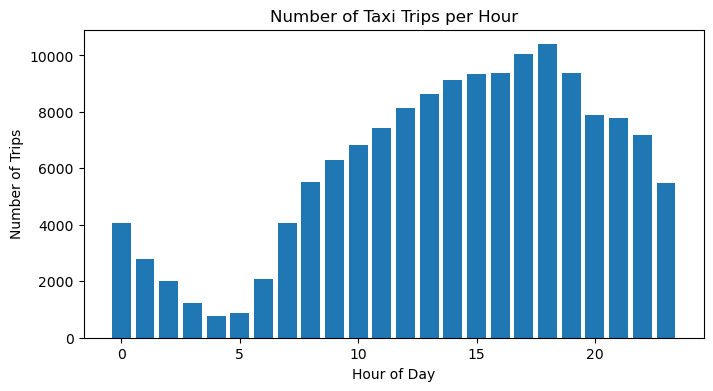

In [56]:
plt.figure(figsize=(8, 4))
plt.bar(trips_per_hour.index, trips_per_hour.values)
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.title("Number of Taxi Trips per Hour")
plt.show()

In [57]:
busiest_hour = trips_per_hour.idxmax()
busiest_hour_count = trips_per_hour.max()

busiest_hour, busiest_hour_count

(np.int32(18), 10391)

Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [59]:
# Scale up the number of trips

# Fill in the value of your sampling fraction and use that to scale up the numbers
sample_fraction = 0.05

In [60]:
scaled_trips_per_hour = trips_per_hour / sample_fraction
scaled_trips_per_hour

pickup_hour
0      81480.0
1      55640.0
2      39900.0
3      24420.0
4      15640.0
5      17280.0
6      41280.0
7      81060.0
8     110620.0
9     126140.0
10    136740.0
11    148700.0
12    162820.0
13    172540.0
14    182480.0
15    186620.0
16    187840.0
17    201120.0
18    207820.0
19    187220.0
20    157800.0
21    155960.0
22    143680.0
23    109720.0
Name: count, dtype: float64

In [61]:
scaled_busiest_hour = scaled_trips_per_hour.idxmax()
scaled_busiest_hour_trips = scaled_trips_per_hour.max()

scaled_busiest_hour, scaled_busiest_hour_trips

(np.int32(18), 207820.0)

**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

In [62]:
# Compare traffic trends for the week days and weekends

df_sample["day_type"] = df_sample["pickup_day"].apply(
    lambda x: "Weekend" if x in ["Saturday", "Sunday"] else "Weekday"
)

In [63]:
hourly_daytype_trips = (
    df_sample
    .groupby(["day_type", "pickup_hour"])
    .size()
    .reset_index(name="trip_count")
)

hourly_daytype_trips.head()

,day_type,pickup_hour,trip_count
0,Weekday,0,1756
1,Weekday,1,881
2,Weekday,2,501
3,Weekday,3,294
4,Weekday,4,273


In [64]:
hourly_pivot = hourly_daytype_trips.pivot(
    index="pickup_hour",
    columns="day_type",
    values="trip_count"
)

hourly_pivot

day_type,Weekday,Weekend
pickup_hour,,
0,1756,2318
1,881,1901
2,501,1494
3,294,927
4,273,509
5,636,228
6,1714,350
7,3511,542
8,4728,803


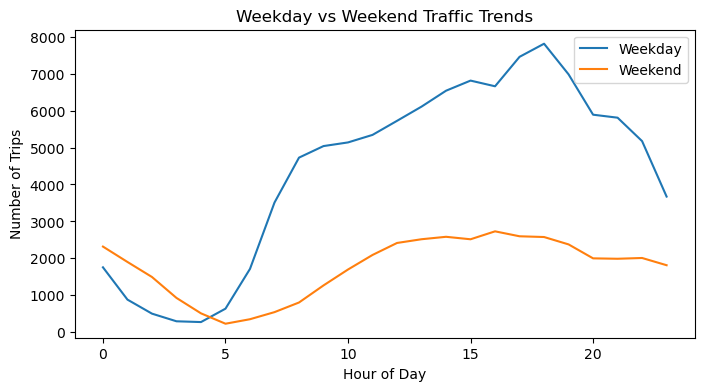

In [65]:
plt.figure(figsize=(8, 4))
plt.plot(hourly_pivot.index, hourly_pivot["Weekday"], label="Weekday")
plt.plot(hourly_pivot.index, hourly_pivot["Weekend"], label="Weekend")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.title("Weekday vs Weekend Traffic Trends")
plt.legend()
plt.show()

In [66]:
hourly_pivot_scaled = hourly_pivot / sample_fraction
hourly_pivot_scaled

day_type,Weekday,Weekend
pickup_hour,,
0,35120.0,46360.0
1,17620.0,38020.0
2,10020.0,29880.0
3,5880.0,18540.0
4,5460.0,10180.0
5,12720.0,4560.0
6,34280.0,7000.0
7,70220.0,10840.0
8,94560.0,16060.0


What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

In [67]:
# Find top 10 pickup and dropoff zones

top_pickup_zones = (
    df_sample["PULocationID"]
    .value_counts()
    .head(10)
)

top_pickup_zones

PULocationID
132    7764
237    7271
236    6669
161    6585
162    5216
186    5202
230    4878
142    4786
138    4373
239    4240
Name: count, dtype: int64

In [68]:
top_dropoff_zones = (
    df_sample["DOLocationID"]
    .value_counts()
    .head(10)
)

top_dropoff_zones

DOLocationID
236    6942
237    6514
161    5463
230    4374
170    4333
141    4292
142    4273
239    4273
162    3930
48     3733
Name: count, dtype: int64

In [69]:
pickup_trends = df_sample[
    df_sample["PULocationID"].isin(top_pickup_zones.index)
]

In [70]:
pickup_hourly_trends = (
    pickup_trends
    .groupby(["PULocationID", "pickup_hour"])
    .size()
    .reset_index(name="trip_count")
)

pickup_hourly_trends.head()

,PULocationID,pickup_hour,trip_count
0,132,0,285
1,132,1,126
2,132,2,43
3,132,3,23
4,132,4,19


In [71]:
dropoff_trends = df_sample[
    df_sample["DOLocationID"].isin(top_dropoff_zones.index)
]

In [72]:
dropoff_hourly_trends = (
    dropoff_trends
    .groupby(["DOLocationID", "pickup_hour"])
    .size()
    .reset_index(name="trip_count")
)

dropoff_hourly_trends.head()

,DOLocationID,pickup_hour,trip_count
0,48,0,129
1,48,1,97
2,48,2,65
3,48,3,50
4,48,4,31


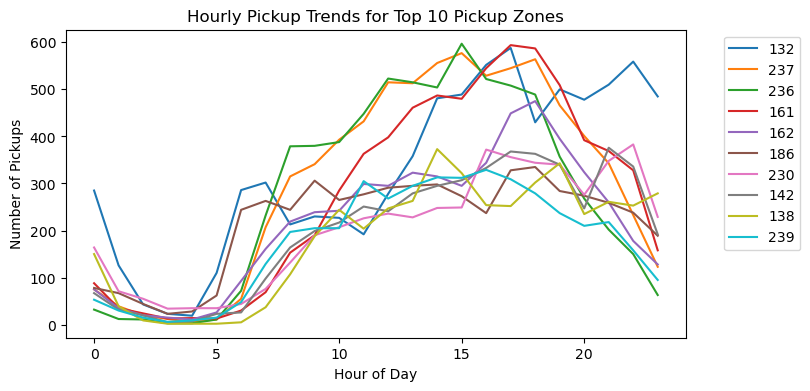

In [73]:
plt.figure(figsize=(8, 4))
for zone in top_pickup_zones.index:
    zone_data = pickup_hourly_trends[
        pickup_hourly_trends["PULocationID"] == zone
    ]
    plt.plot(zone_data["pickup_hour"], zone_data["trip_count"], label=str(zone))

plt.xlabel("Hour of Day")
plt.ylabel("Number of Pickups")
plt.title("Hourly Pickup Trends for Top 10 Pickup Zones")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [74]:
# Find the top 10 and bottom 10 pickup/dropoff ratios

pickup_counts = (
    df_sample["PULocationID"]
    .value_counts()
    .reset_index()
)

pickup_counts.columns = ["LocationID", "pickup_count"]
pickup_counts.head()

,LocationID,pickup_count
0,132,7764
1,237,7271
2,236,6669
3,161,6585
4,162,5216


In [75]:
dropoff_counts = (
    df_sample["DOLocationID"]
    .value_counts()
    .reset_index()
)

dropoff_counts.columns = ["LocationID", "dropoff_count"]
dropoff_counts.head()

,LocationID,dropoff_count
0,236,6942
1,237,6514
2,161,5463
3,230,4374
4,170,4333


In [76]:
pickup_dropoff = pickup_counts.merge(
    dropoff_counts,
    on="LocationID",
    how="outer"
)

In [77]:
pickup_dropoff[["pickup_count", "dropoff_count"]] = (
    pickup_dropoff[["pickup_count", "dropoff_count"]].fillna(0)
)

In [78]:
pickup_dropoff["pickup_dropoff_ratio"] = (
    pickup_dropoff["pickup_count"] /
    pickup_dropoff["dropoff_count"].replace(0, np.nan)
)

In [79]:
pickup_dropoff = pickup_dropoff.merge(
    taxi_zones[["LocationID", "zone", "borough"]],
    on="LocationID",
    how="left"
)

In [80]:
top_10_ratios = (
    pickup_dropoff
    .sort_values("pickup_dropoff_ratio", ascending=False)
    .head(10)
)

top_10_ratios[["LocationID", "zone", "borough", "pickup_dropoff_ratio"]]

,LocationID,zone,borough,pickup_dropoff_ratio
69,70,East Elmhurst,Queens,10.245902
199,207,Saint Michaels Cemetery/Woodside,Queens,6.000000
127,132,JFK Airport,Queens,5.593660
133,138,LaGuardia Airport,Queens,3.015862
256,264,NaN,NaN,1.965921
181,186,Penn Station/Madison Sq West,Manhattan,1.664640
241,249,West Village,Manhattan,1.403030
157,162,Midtown East,Manhattan,1.327226
42,43,Central Park,Manhattan,1.323416
109,114,Greenwich Village South,Manhattan,1.319565


In [81]:
bottom_10_ratios = (
    pickup_dropoff
    .sort_values("pickup_dropoff_ratio", ascending=True)
    .head(10)
)

bottom_10_ratios[["LocationID", "zone", "borough", "pickup_dropoff_ratio"]]

,LocationID,zone,borough,pickup_dropoff_ratio
30,31,Bronx Park,Bronx,0.0
26,27,Breezy Point/Fort Tilden/Riis Beach,Queens,0.0
213,221,Stapleton,Staten Island,0.0
237,245,West Brighton,Staten Island,0.0
189,195,Red Hook,Brooklyn,0.0
179,184,Pelham Bay Park,Bronx,0.0
45,46,City Island,Bronx,0.0
206,214,South Beach/Dongan Hills,Staten Island,0.0
180,185,Pelham Parkway,Bronx,0.0
178,183,Pelham Bay,Bronx,0.0


**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

In [82]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones

trips_per_hour = df_sample["pickup_hour"].value_counts().sort_index()
trips_per_hour

pickup_hour
0      4074
1      2782
2      1995
3      1221
4       782
5       864
6      2064
7      4053
8      5531
9      6307
10     6837
11     7435
12     8141
13     8627
14     9124
15     9331
16     9392
17    10056
18    10391
19     9361
20     7890
21     7798
22     7184
23     5486
Name: count, dtype: int64

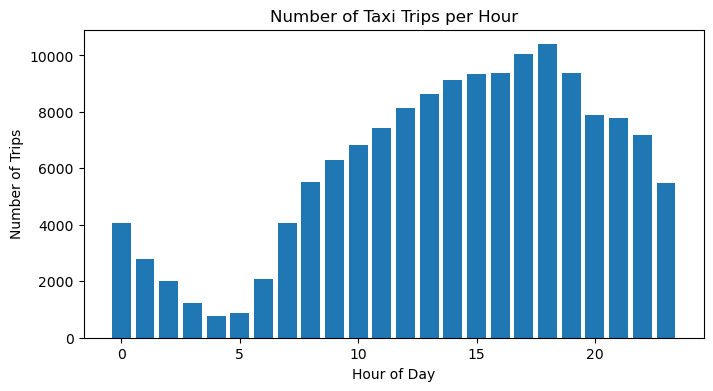

In [83]:
plt.figure(figsize=(8, 4))
plt.bar(trips_per_hour.index, trips_per_hour.values)
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.title("Number of Taxi Trips per Hour")
plt.show()

In [84]:
busiest_hour = trips_per_hour.idxmax()
busiest_hour_count = trips_per_hour.max()

busiest_hour, busiest_hour_count

(np.int32(18), 10391)

Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

In [86]:
# Filter for night hours (11 PM to 5 AM)

night_hours = [23, 0, 1, 2, 3, 4, 5]

In [87]:
night_data = df_sample[df_sample["pickup_hour"].isin(night_hours)]
day_data = df_sample[~df_sample["pickup_hour"].isin(night_hours)]

In [88]:
night_revenue = night_data["total_amount"].sum()
day_revenue = day_data["total_amount"].sum()

night_revenue, day_revenue

(np.float64(493736.77999999997), np.float64(3513077.6099999994))

In [89]:
total_revenue = night_revenue + day_revenue
total_revenue

np.float64(4006814.389999999)

In [90]:
night_revenue_share = night_revenue / total_revenue
day_revenue_share = day_revenue / total_revenue

night_revenue_share, day_revenue_share

(np.float64(0.1232242704409375), np.float64(0.8767757295590626))

##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

In [92]:
# Analyse the fare per mile per passenger for different passenger counts


df_pricing = df_sample[
    (df_sample["trip_distance"] > 0) &
    (df_sample["passenger_count"] > 0)
]

In [93]:
df_pricing["fare_per_mile"] = (
    df_pricing["fare_amount"] / df_pricing["trip_distance"]
)

In [94]:
avg_fare_per_mile = (
    df_pricing
    .groupby("passenger_count")["fare_per_mile"]
    .mean()
)

avg_fare_per_mile

passenger_count
1.0     9.568718
2.0     9.644614
3.0     8.282696
4.0    13.400103
5.0     7.728999
6.0     7.683482
Name: fare_per_mile, dtype: float64

In [95]:
avg_fare_per_mile = (
    df_pricing
    .groupby("passenger_count")["fare_per_mile"]
    .mean()
)

avg_fare_per_mile

passenger_count
1.0     9.568718
2.0     9.644614
3.0     8.282696
4.0    13.400103
5.0     7.728999
6.0     7.683482
Name: fare_per_mile, dtype: float64

**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

In [96]:
# Compare the average fare per mile for different days and for different times of the day

df_fare_mile = df_sample[
    (df_sample["trip_distance"] > 0)
]

In [97]:
df_fare_mile["fare_per_mile"] = (
    df_fare_mile["fare_amount"] / df_fare_mile["trip_distance"]
)

In [98]:
avg_fare_per_mile_hour = (
    df_fare_mile
    .groupby("pickup_hour")["fare_per_mile"]
    .mean()
    .sort_index()
)

avg_fare_per_mile_hour

pickup_hour
0      9.663799
1     12.172886
2      6.748347
3      7.011233
4     31.757573
5     21.811487
6      7.539921
7      7.453199
8      9.588819
9      9.298920
10     8.338928
11     9.957713
12     9.098320
13    10.867674
14     8.940821
15     8.919572
16     9.311083
17     8.997140
18    11.273489
19     9.016015
20     7.311665
21    10.611310
22     8.731625
23    10.247924
Name: fare_per_mile, dtype: float64

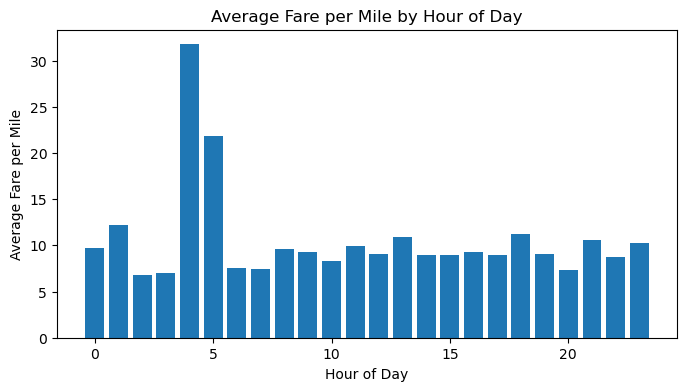

In [99]:
plt.figure(figsize=(8, 4))
plt.bar(avg_fare_per_mile_hour.index, avg_fare_per_mile_hour.values)
plt.xlabel("Hour of Day")
plt.ylabel("Average Fare per Mile")
plt.title("Average Fare per Mile by Hour of Day")
plt.show()

In [100]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

avg_fare_per_mile_day = (
    df_fare_mile
    .groupby("pickup_day")["fare_per_mile"]
    .mean()
    .reindex(day_order)
)

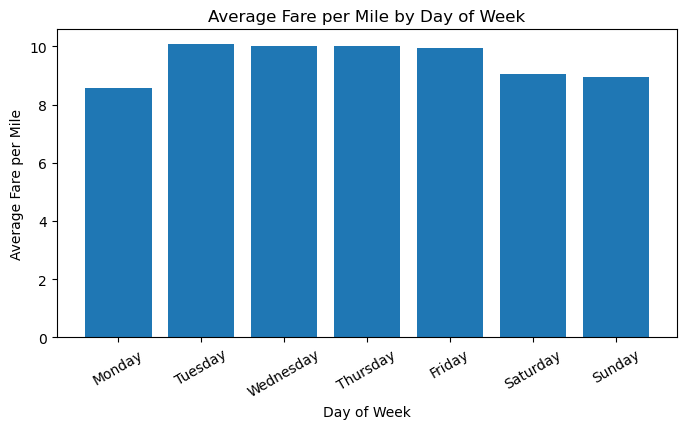

In [101]:
plt.figure(figsize=(8, 4))
plt.bar(avg_fare_per_mile_day.index, avg_fare_per_mile_day.values)
plt.xlabel("Day of Week")
plt.ylabel("Average Fare per Mile")
plt.title("Average Fare per Mile by Day of Week")
plt.xticks(rotation=30)
plt.show()

**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

In [102]:
# Compare fare per mile for different vendors

df_vendor = df[
    (df["trip_distance"] > 0)
].copy()

df_vendor["fare_per_mile"] = df_vendor["fare_amount"] / df_vendor["trip_distance"]

In [105]:
vendor_hour_fare = (
    df_vendor
    .groupby(["VendorID", "pickup_hour"])["fare_per_mile"]
    .mean()
    .reset_index()
)

**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


In [115]:
# Defining distance tiers

df_vendor = df[df["trip_distance"] > 0].copy()
df_vendor["fare_per_mile"] = df_vendor["fare_amount"] / df_vendor["trip_distance"]

In [111]:
vendor_tier_fare = (
    df_vendor
    .groupby(["VendorID", "distance_tier"])["fare_per_mile"]
    .mean()
    .reset_index()
)

In [112]:
vendor_tier_fare.head()

,VendorID,distance_tier,fare_per_mile
0,1,Up to 2 miles,9.112578
1,1,2 to 5 miles,5.987434
2,1,More than 5 miles,4.301158
3,2,Up to 2 miles,16.175099
4,2,2 to 5 miles,6.194479


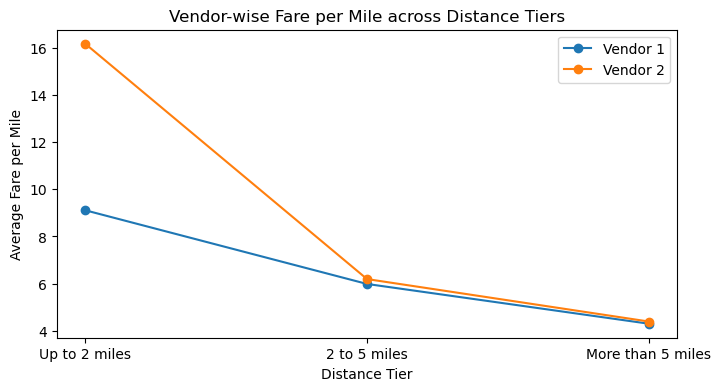

In [116]:
plt.figure(figsize=(8, 4))
for vendor in vendor_tier_fare["VendorID"].unique():
    data = vendor_tier_fare[vendor_tier_fare["VendorID"] == vendor]
    plt.plot(data["distance_tier"], data["fare_per_mile"], marker="o", label=f"Vendor {vendor}")

plt.xlabel("Distance Tier")
plt.ylabel("Average Fare per Mile")
plt.title("Vendor-wise Fare per Mile across Distance Tiers")
plt.legend()
plt.show()

##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

In [125]:
#  Analyze tip percentages based on distances, passenger counts and pickup times

df_tip = df_sample[df_sample["fare_amount"] > 0].copy()
df_tip["tip_pct"] = (df_tip["tip_amount"] / df_tip["fare_amount"]) * 100

In [126]:
tip_by_distance = (
    df_tip.groupby("trip_distance")["tip_pct"]
    .mean()
)
tip_by_distance.head()

trip_distance
0.01     7.907413
0.02     4.456137
0.03    16.264928
0.04     7.351074
0.05     7.463163
Name: tip_pct, dtype: float64

In [127]:
tip_by_passenger = (
    df_tip.groupby("passenger_count")["tip_pct"]
    .mean()
)
tip_by_passenger

passenger_count
0.0    20.025703
1.0    20.797049
2.0    20.134224
3.0    19.589692
4.0    17.934527
5.0    21.301336
6.0    20.480230
Name: tip_pct, dtype: float64

In [128]:
tip_by_hour = (
    df_tip.groupby("pickup_hour")["tip_pct"]
    .mean()
)
tip_by_hour

pickup_hour
0     19.829580
1     21.057099
2     21.101766
3     20.424292
4     18.758546
5     16.520529
6     17.678559
7     19.345461
8     19.989669
9     19.774600
10    19.271408
11    19.542440
12    19.539601
13    19.509460
14    19.486361
15    19.502196
16    21.405514
17    22.055381
18    22.366380
19    22.567085
20    21.679530
21    21.583012
22    21.323221
23    20.626150
Name: tip_pct, dtype: float64

In [120]:
comparison = pd.DataFrame({
    "Low Tip (<10%)": low_tip_trips[["trip_distance", "trip_duration", "fare_amount"]].mean(),
    "High Tip (>25%)": high_tip_trips[["trip_distance", "trip_duration", "fare_amount"]].mean()
})

comparison

,Low Tip (<10%),High Tip (>25%)
trip_distance,3.841960,2.227119
trip_duration,17.993868,11.611925
fare_amount,20.274033,13.573424


Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [121]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%

df_tip = df_sample[df_sample["fare_amount"] > 0].copy()

In [122]:
df_tip["tip_pct"] = (df_tip["tip_amount"] / df_tip["fare_amount"]) * 100

In [123]:
low_tip_trips = df_tip[df_tip["tip_pct"] < 10]
high_tip_trips = df_tip[df_tip["tip_pct"] > 25]

In [124]:
comparison = pd.DataFrame({
    "Low Tip (<10%)": low_tip_trips[["trip_distance", "trip_duration", "fare_amount"]].mean(),
    "High Tip (>25%)": high_tip_trips[["trip_distance", "trip_duration", "fare_amount"]].mean()
})

comparison

,Low Tip (<10%),High Tip (>25%)
trip_distance,3.841960,2.227119
trip_duration,17.993868,11.611925
fare_amount,20.274033,13.573424


**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

In [129]:
# See how passenger count varies across hours and days


passenger_by_hour = (
    df_sample
    .groupby("pickup_hour")["passenger_count"]
    .mean()
    .sort_index()
)

passenger_by_hour

pickup_hour
0     1.444281
1     1.412293
2     1.426065
3     1.438984
4     1.346547
5     1.326389
6     1.250969
7     1.277325
8     1.277888
9     1.295386
10    1.321632
11    1.349563
12    1.377349
13    1.358178
14    1.370671
15    1.375737
16    1.379578
17    1.366846
18    1.340487
19    1.368550
20    1.385932
21    1.412542
22    1.393653
23    1.390995
Name: passenger_count, dtype: float64

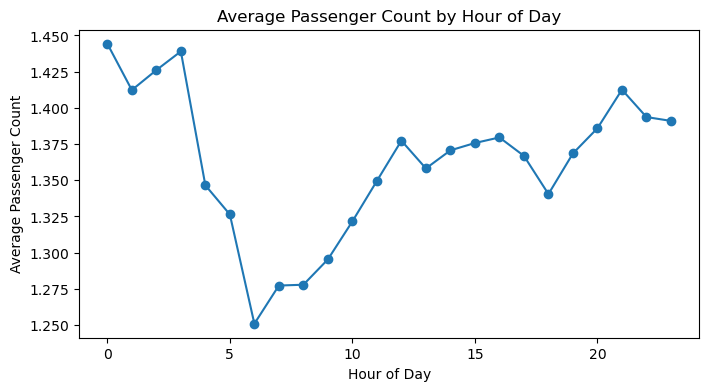

In [130]:
plt.figure(figsize=(8, 4))
plt.plot(passenger_by_hour.index, passenger_by_hour.values, marker="o")
plt.xlabel("Hour of Day")
plt.ylabel("Average Passenger Count")
plt.title("Average Passenger Count by Hour of Day")
plt.show()

In [131]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

passenger_by_day = (
    df_sample
    .groupby("pickup_day")["passenger_count"]
    .mean()
    .reindex(day_order)
)

passenger_by_day

pickup_day
Monday       1.358154
Tuesday      1.306104
Wednesday    1.311914
Thursday     1.324405
Friday       1.357710
Saturday     1.440630
Sunday       1.444952
Name: passenger_count, dtype: float64

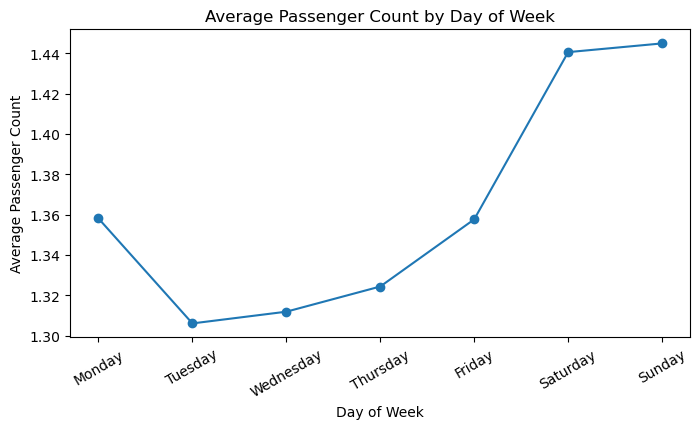

In [132]:
plt.figure(figsize=(8, 4))
plt.plot(passenger_by_day.index, passenger_by_day.values, marker="o")
plt.xlabel("Day of Week")
plt.ylabel("Average Passenger Count")
plt.title("Average Passenger Count by Day of Week")
plt.xticks(rotation=30)
plt.show()

**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

In [133]:
# How does passenger count vary across zones

passenger_by_zone = (
    df_sample
    .groupby("PULocationID")["passenger_count"]
    .mean()
    .reset_index()
)

passenger_by_zone.head()

,PULocationID,passenger_count
0,1,1.000000
1,3,1.000000
2,4,1.474576
3,7,1.200000
4,10,1.522388


In [134]:
passenger_by_zone = (
    df_sample
    .groupby("PULocationID")["passenger_count"]
    .mean()
    .reset_index()
)

passenger_by_zone.head()

,PULocationID,passenger_count
0,1,1.000000
1,3,1.000000
2,4,1.474576
3,7,1.200000
4,10,1.522388


In [136]:
passenger_by_zone.columns

Index(['PULocationID', 'passenger_count'], dtype='object')

In [137]:
passenger_by_zone = passenger_by_zone.merge(
    taxi_zones[["LocationID", "zone", "borough"]],
    left_on="PULocationID",
    right_on="LocationID",
    how="left"
)

In [138]:
passenger_by_zone.columns

Index(['PULocationID', 'passenger_count', 'LocationID', 'zone', 'borough'], dtype='object')

In [139]:
passenger_by_zone_sorted = passenger_by_zone.sort_values(
    by="passenger_count",
    ascending=False
)

passenger_by_zone_sorted[["zone", "borough", "passenger_count"]].head(10)

,zone,borough,passenger_count
105,Hunts Point,Bronx,4.000000
133,Marine Park/Floyd Bennett Field,Brooklyn,3.000000
29,Bushwick South,Brooklyn,2.250000
93,Green-Wood Cemetery,Brooklyn,2.000000
203,Van Cortlandt Park,Bronx,2.000000
218,Woodhaven,Queens,2.000000
6,Battery Park,Manhattan,1.939394
158,Prospect Heights,Brooklyn,1.909091
72,Elmhurst/Maspeth,Queens,1.800000
55,DUMBO/Vinegar Hill,Brooklyn,1.789474


In [140]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.

avg_passenger_zone = (
    df_sample
    .groupby("PULocationID")["passenger_count"]
    .mean()
    .reset_index()
)

avg_passenger_zone.columns = ["LocationID", "avg_passenger_count"]

In [141]:
zones_with_trips = zones_with_counts.merge(
    avg_passenger_zone,
    on="LocationID",
    how="left"
)

In [142]:
zones_with_trips = zones_with_counts.merge(
    avg_passenger_zone,
    on="LocationID",
    how="left"
)

In [143]:
zones_with_trips["avg_passenger_count"] = (
    zones_with_trips["avg_passenger_count"].fillna(0)
)

Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

In [144]:
# How often is each surcharge applied?

surcharge_frequency = {
    "extra": (df_sample["extra"] > 0).sum(),
    "mta_tax": (df_sample["mta_tax"] > 0).sum(),
    "improvement_surcharge": (df_sample["improvement_surcharge"] > 0).sum(),
    "congestion_surcharge": (df_sample["congestion_surcharge"] > 0).sum(),
    "airport_fee": (df_sample["airport_fee"] > 0).sum()
}

surcharge_frequency

{'extra': np.int64(89810),
 'mta_tax': np.int64(145973),
 'improvement_surcharge': np.int64(146722),
 'congestion_surcharge': np.int64(136481),
 'airport_fee': np.int64(12865)}

In [145]:
surcharge_by_hour = (
    df_sample[df_sample["extra"] > 0]
    .groupby("pickup_hour")
    .size()
)

surcharge_by_hour

pickup_hour
0     3941
1     2718
2     1964
3     1195
4      736
5      735
6      686
7     1243
8     1649
9     1967
10    2162
11    2245
12    2496
13    2565
14    2909
15    2909
16    6888
17    7885
18    8208
19    7386
20    7567
21    7557
22    6937
23    5262
dtype: int64

In [146]:
surcharge_by_zone = (
    df_sample[df_sample["extra"] > 0]
    .groupby("PULocationID")
    .size()
    .reset_index(name="count")
)

surcharge_by_zone = surcharge_by_zone.merge(
    taxi_zones[["LocationID", "zone", "borough"]],
    left_on="PULocationID",
    right_on="LocationID",
    how="left"
)
surcharge_by_zone.sort_values("count", ascending=False).head(10)

,PULocationID,count,LocationID,zone,borough
70,138,4336,138.0,LaGuardia Airport,Queens
84,161,4222,161.0,Midtown Center,Manhattan
128,237,4119,237.0,Upper East Side South,Manhattan
67,132,4016,132.0,JFK Airport,Queens
127,236,3478,236.0,Upper East Side North,Manhattan
121,230,3304,230.0,Times Sq/Theatre District,Manhattan
85,162,3198,162.0,Midtown East,Manhattan
96,186,3038,186.0,Penn Station/Madison Sq West,Manhattan
73,142,2954,142.0,Lincoln Square East,Manhattan
43,79,2950,79.0,East Village,Manhattan


## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

-Deploy more taxis during peak hours
More taxis should be available during weekday mornings and evenings to reduce waiting time.

-Focus on high-demand zones
Zones with consistently high pickups, such as central city areas and airports, should receive priority dispatching.

-Separate night-time strategy
Night-time demand follows different patterns, so taxis should be positioned near nightlife and transport hubs.

-Reduce idle time using zone balance
Taxis can be moved from dropoff-heavy zones to pickup-heavy zones to improve efficiency.

-Use pricing and incentives wisely
Higher fares during busy hours can be used to encourage more drivers to operate during high-demand periods.

**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

Place more cabs in office areas during weekday peak hours.

Move cabs to shopping and entertainment zones on weekends.

Deploy more cabs near nightlife areas and airports at night.

Keep enough cabs available around airports throughout the day.

Shift idle cabs from low-demand zones to high-demand zones.

Use monthly demand trends to plan cab availability in advance.

**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.

Increase prices slightly during peak hours when demand is high.

Apply higher fares during late-night hours to match higher operating demand.

Keep prices competitive during off-peak hours to attract more riders.

Offer lower per-mile fares for longer trips to encourage usage.

Use zone-based pricing for high-demand areas like airports and city centers.

Provide driver incentives instead of fare hikes in sensitive price zones.